In [1]:
# cleanup and fix isogeometric plate case
# first let's plot the basis functions from _plate.py
import numpy as np

# 1) make the open knot vector
nxe, p = 5, 3
# nxe, p = 4, 1
knots = [0.0]*(p+1) + [i/nxe for i in range(1,nxe)] + [1.0]*(p+1)
print(f"{knots=}")
n_ctrl = nxe + p # number of control ponts

# 2) find span to determine where in vector to do interpolations
def find_span(n_ctrl, degree, u, U):
    # Cox-de Boor span search (n_ctrl = number of control points)
    if u >= U[-1] - 1e-12:
        return n_ctrl - 1
    low = degree
    high = len(U)-degree-1
    mid = (low+high)//2
    while True:
        if u < U[mid]:
            high = mid
        elif u >= U[mid+1]:
            low = mid
        else:
            return mid
        mid = (low+high)//2

# get basis functions

def basis_functions_and_derivatives(span, u, degree, U, n_deriv=1):
    # Compute nonzero basis functions and first derivatives using Cox-de Boor + derivative formula
    # Returns arrays N[0:degree] and dN[0:degree]
    left = np.zeros(degree+1)
    right = np.zeros(degree+1)
    ndu = np.zeros((degree+1, degree+1))
    ndu[0,0] = 1.0
    for j in range(1, degree+1):
        left[j] = u - U[span+1-j]
        right[j] = U[span+j] - u
        saved = 0.0
        for r in range(j):
            ndu[j,r] = right[r+1] + left[j-r]
            temp = ndu[r,j-1]/ndu[j,r]
            ndu[r,j] = saved + right[r+1]*temp
            saved = left[j-r]*temp
        ndu[j,j] = saved
    N = ndu[:,degree].copy()
    # derivatives
    ders = np.zeros((n_deriv+1, degree+1))
    a = np.zeros((2, degree+1))
    # compute a triangular table of derivatives
    for r in range(degree+1):
        s1 = 0; s2 = 1
        a[0,0] = 1.0
        for k in range(1, n_deriv+1):
            d = 0.0
            rk = r - k
            pk = degree - k
            if r >= k:
                a[s2,0] = a[s1,0]/ndu[pk+1,rk]
                d = a[s2,0]*ndu[rk,pk]
            j1 = 1 if rk >= -1 else -rk
            j2 = k-1 if r-1 <= pk else degree - r
            for j in range(j1, j2+1):
                a[s2,j] = (a[s1,j] - a[s1,j-1]) / ndu[pk+1, rk+j]
                d += a[s2,j]*ndu[rk+j, pk]
            if r <= pk:
                a[s2,k] = -a[s1,k-1]/ndu[pk+1, r]
                d += a[s2,k]*ndu[r, pk]
            ders[k,r] = d
            s1, s2 = s2, s1
    # Multiply by correct factors
    for k in range(1, n_deriv+1):
        for j in range(degree+1):
            ders[k,j] *= degree
    return N, ders[1]

knots=[0.0, 0.0, 0.0, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.0, 1.0, 1.0]


ndegen_knots=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]


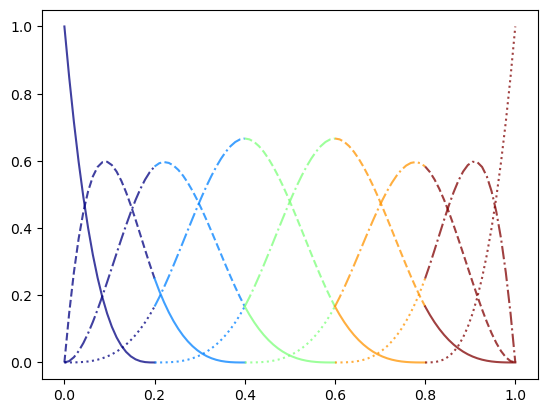

In [2]:
# now plot each separate basis function in the span?
import matplotlib.pyplot as plt

ielem = 0
colors = plt.cm.jet(np.linspace(0.0, 1.0, nxe))
linestyles = ['-', '--', '-.', ':']

ndegen_knots = knots[p:(nxe+1+p)]
print(f"{ndegen_knots=}")
for i in range(len(ndegen_knots)-1):
    knot1 = ndegen_knots[i]; knot2 = ndegen_knots[i+1]
    # print(f"{knot1=} {knot2=}")
    dknot = knot2 - knot1
    if abs(dknot) > 1e-12:
        uvec = np.linspace(knot1, knot2, 20)
        span = find_span(n_ctrl, p, np.mean(uvec), knots)  # gets starting index?
        Nvals = np.zeros((p+1, uvec.shape[0]))
        for ii, _u in enumerate(uvec):
            N, deriv = basis_functions_and_derivatives(span, _u, p, knots, n_deriv=1)
            Nvals[:,ii] = N[:]

        for iN in range(p+1):
            rand_scale = 0.0
            # rand_scale = 0.05
            plt.plot(uvec, Nvals[iN,:] + np.random.rand(1)*rand_scale, linestyle=linestyles[iN], color=colors[ielem], alpha=0.75)
        
        ielem += 1
plt.show()


ndegen_knots=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]


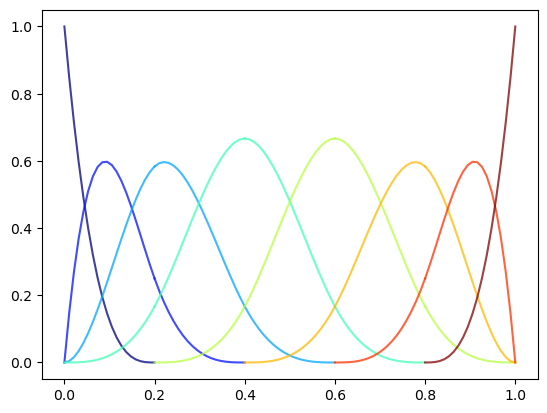

In [3]:
"""
plot it again with the colors of each basis fcn
"""
import matplotlib.pyplot as plt

ielem = 0
colors = plt.cm.jet(np.linspace(0.0, 1.0, nxe + p))
linestyles = ['-', '--', '-.', ':']

ndegen_knots = knots[p:(nxe+1+p)]
print(f"{ndegen_knots=}")
for i in range(len(ndegen_knots)-1):
    knot1 = ndegen_knots[i]; knot2 = ndegen_knots[i+1]
    # print(f"{knot1=} {knot2=}")
    dknot = knot2 - knot1
    if abs(dknot) > 1e-12:
        uvec = np.linspace(knot1, knot2, 20)
        span = find_span(n_ctrl, p, np.mean(uvec), knots)  # gets starting index?
        Nvals = np.zeros((p+1, uvec.shape[0]))
        for ii, _u in enumerate(uvec):
            N, deriv = basis_functions_and_derivatives(span, _u, p, knots, n_deriv=1)
            Nvals[:,ii] = N[:]

        for iN in range(p+1):
            rand_scale = 0.0
            # rand_scale = 0.05
            icolor = ielem + iN
            plt.plot(
                uvec, 
                Nvals[iN,:] + np.random.rand(1)*rand_scale, 
                # linestyle=linestyles[iN],
                linestyle='-', 
                color=colors[icolor], 
                alpha=0.75
            )
        
        ielem += 1
plt.show()

nxe=5 p=3 nglob=8


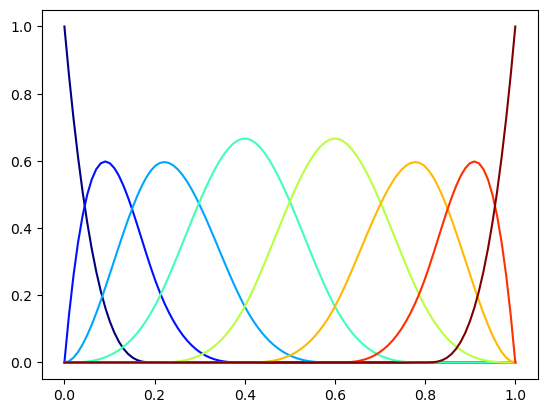

In [ ]:
def cubic_bernstein(xi):
    N  = np.array([
        (1 - xi)**3,
        3*xi*(1 - xi)**2,
        3*xi**2*(1 - xi),
        xi**3
    ])
    dN = np.array([
        -3*(1 - xi)**2,
        3*(1 - xi)**2 - 6*xi*(1 - xi),
        6*xi*(1 - xi) - 3*xi**2,
        3*xi**2
    ])
    return N, dN


u = np.linspace(0.0, 1.0, 100)
nglob = nxe + p
print(f"{nxe=} {p=} {nglob=}")
global_basis = np.zeros((nglob, u.shape[0]))

# local basis to global basis connectivities?
elem_conn = [
    [i, i+1, i+2, i+3] for i in range(nxe) # element connectivity
]

# for order 2 get the list of nonzero knot pairs (pre-computed)
# print(f"{ndegen_knots=}")
for ielem in range(nxe):
# for ielem in range(1):
    knot1, knot2 = knots[p+ielem], knots[p+ielem+1]
    # compute normalized coordinates in here
    xi = (u - knot1) / (knot2 - knot1)
    # zero out using mask products if xi not in 0, 1
    xi_mask = np.logical_and(xi >= 0.0, xi <= 1.0)
    # compute bernstein coefficients
    B, dB = cubic_bernstein(xi)

    first_elem  = (ielem == 0)
    second_elem = (ielem == 1)
    last_elem   = (ielem == nxe - 1)
    second_last = (ielem == nxe - 2)
    interior    = not (first_elem or second_elem or last_elem or second_last)

    if first_elem:
        N0 = 1.0 * B[0]
        N1 = 1.0 * B[1] + 0.5 * B[2] + 0.25 * B[3]
        N2 = 0.5 * B[2] + (7.0/12.0) * B[3]
        N3 = (1.0/6.0) * B[3]

    elif second_elem:
        N0 = 0.25 * B[0]
        N1 = (7.0/12.0)*B[0] + (2.0/3.0)*B[1] + (1.0/3.0)*B[2] + (1.0/6.0)*B[3]
        N2 = (1.0/6.0)*B[0] + (1.0/3.0)*B[1] + (2.0/3.0)*B[2] + (2.0/3.0)*B[3]
        N3 = (1.0/6.0) * B[3]

    elif second_last:
        # mirror of second
        N0 = (1.0/6.0) * B[0]
        N1 = (2.0/3.0)*B[0] + (2.0/3.0)*B[1] + (1.0/3.0)*B[2] + (1.0/6.0)*B[3]
        N2 = (1.0/6.0)*B[0] + (1.0/3.0)*B[1] + (2.0/3.0)*B[2] + (7.0/12.0)*B[3]
        N3 = 0.25 * B[3]

    elif last_elem:
        # mirror of first
        N0 = (1.0/6.0) * B[0]
        N1 = (7.0/12.0) * B[0] + 0.5 * B[1]
        N2 = 0.25 * B[0] + 0.5 * B[1] + 1.0 * B[2]
        N3 = 1.0 * B[3]

    else:  # interior
        N0 = (1.0/6.0) * B[0]

        N1 = (2.0/3.0)*B[0] + (2.0/3.0)*B[1] \
        + (1.0/3.0)*B[2] + (1.0/6.0)*B[3]

        N2 = (1.0/6.0)*B[0] + (1.0/3.0)*B[1] \
        + (2.0/3.0)*B[2] + (2.0/3.0)*B[3]

        N3 = (1.0/6.0) * B[3]



    # now add into these basis functions if they exist
    local_conn = elem_conn[ielem]
    g0, g1, g2, g3 = local_conn[0], local_conn[1], local_conn[2], local_conn[3]
    global_basis[g0] += N0 * xi_mask
    global_basis[g1] += N1 * xi_mask
    global_basis[g2] += N2 * xi_mask
    global_basis[g3] += N3 * xi_mask

# now plot each global basis function
colors = plt.cm.jet(np.linspace(0.0, 1.0, nglob))
for iglob in range(nglob):
    plt.plot(u, global_basis[iglob], color=colors[iglob])
plt.show()